# Stage 8: Predictive Modelling

**Dissertation title:**  
Spatio-Temporal Analysis and Visualisation of Persistent Road Traffic Collision Hotspots in Great Britain

In this stage, I am trying to predict whether a 5 km grid cell will be a hotspot in the following year.

The target variable is:

`target_is_hotspot`

I will mainly use information from the previous year so that I do not accidentally use future information.

## What I am trying to predict

For every grid cell, the model will predict:

- `0` = not a hotspot in the target year
- `1` = hotspot in the target year

The main question is:

**Can previous-year collision activity help predict whether the same grid cell will be a hotspot next year?**

## Modelling approach

I am going to start with a simple baseline and then gradually try more flexible models.

The order will be:

1. Dummy classifier
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. XGBoost, if it is available

I will avoid random train-test splitting because this is a temporal prediction problem.

My main final test will be 2024.

## 1. Import the libraries

In [18]:
from google.colab import drive
drive.mount('/content/drive')

# Next check

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Next check

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import joblib

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load the Stage 7 file

In [19]:
file_path = "/content/drive/MyDrive/disseration/stage7_outputs/stage8_temporal_input.csv"

df = pd.read_csv(file_path)

df.head()

,grid_id,target_year,target_is_hotspot,previous_count,log_previous_count,previous_hotspot
0,R000_C005,2021,0,0.0,0.000000,0
1,R000_C005,2022,0,0.0,0.000000,0
2,R000_C005,2023,0,2.0,1.098612,0
3,R000_C005,2024,0,3.0,1.386294,0
4,R000_C021,2021,0,1.0,0.693147,0


I will first check the size and structure because I want to make sure the file has loaded as expected.

In [20]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Next check

df.info()

# Next check

print(df.columns.tolist())

Number of rows: 30424
Number of columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30424 entries, 0 to 30423
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   grid_id             30424 non-null  object 
 1   target_year         30424 non-null  int64  
 2   target_is_hotspot   30424 non-null  int64  
 3   previous_count      30424 non-null  float64
 4   log_previous_count  30424 non-null  float64
 5   previous_hotspot    30424 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.4+ MB
['grid_id', 'target_year', 'target_is_hotspot', 'previous_count', 'log_previous_count', 'previous_hotspot']


## 3. Check the years in the dataset

In [21]:
print(sorted(df["target_year"].unique()))

[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


The target years should be 2021 to 2024 because the predictors use information from the previous year.

In [22]:
df.groupby("target_year").size()

,0
target_year,
2021,7606
2022,7606
2023,7606
2024,7606


## 4. Check the target variable

In [23]:
df["target_is_hotspot"].value_counts()

# Next check

df["target_is_hotspot"].value_counts(normalize=True) * 100

,proportion
target_is_hotspot,
0,91.848541
1,8.151459


This check is important because hotspot cells are expected to be less common than non-hotspot cells.

If class `0` is much larger than class `1`, accuracy on its own will not be a reliable measure.

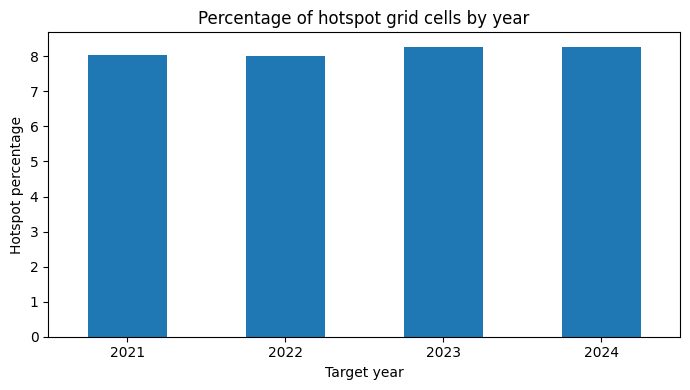

In [24]:
target_by_year = pd.crosstab(
    df["target_year"],
    df["target_is_hotspot"]
)

target_by_year

# Next check

hotspot_rate_by_year = (
    df.groupby("target_year")["target_is_hotspot"]
      .mean()
      .mul(100)
)

hotspot_rate_by_year

# Next check

plt.figure(figsize=(7, 4))
hotspot_rate_by_year.plot(kind="bar")
plt.title("Percentage of hotspot grid cells by year")
plt.xlabel("Target year")
plt.ylabel("Hotspot percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

I am now summarising the target balance from the result above.

In [25]:
overall_hotspot_rate = df["target_is_hotspot"].mean() * 100
non_hotspot_rate = 100 - overall_hotspot_rate

print(
    f"My observation: {overall_hotspot_rate:.2f}% of the grid-year rows "
    f"are hotspots and {non_hotspot_rate:.2f}% are non-hotspots."
)

if overall_hotspot_rate < 20:
    print(
        "The target is clearly imbalanced. A model could achieve high accuracy "
        "by mainly predicting non-hotspots, so recall, hotspot F1 and macro F1 "
        "will be more informative than accuracy alone."
    )
elif overall_hotspot_rate < 35:
    print(
        "There is moderate class imbalance. I will still compare class-sensitive "
        "metrics and consider class weighting."
    )
else:
    print(
        "The classes are reasonably balanced, although I will still report "
        "precision, recall, F1 and ROC-AUC."
    )

rate_range = hotspot_rate_by_year.max() - hotspot_rate_by_year.min()

if rate_range < 2:
    print(
        "The hotspot percentage is fairly stable across the target years."
    )
else:
    highest_year = hotspot_rate_by_year.idxmax()
    lowest_year = hotspot_rate_by_year.idxmin()
    print(
        f"The hotspot percentage changes across years. It is highest in "
        f"{int(highest_year)} and lowest in {int(lowest_year)}."
    )

My observation: 8.15% of the grid-year rows are hotspots and 91.85% are non-hotspots.
The target is clearly imbalanced. A model could achieve high accuracy by mainly predicting non-hotspots, so recall, hotspot F1 and macro F1 will be more informative than accuracy alone.
The hotspot percentage is fairly stable across the target years.


The hotspot percentage should be fairly low because the Stage 6 threshold was based on the top 10% of occupied cells in each year.

However, zero-collision grid cells were also retained, so the hotspot percentage across all rows may be lower than 10%.

## 5. Look at the available predictors

In [26]:
predictor_columns = [
    "previous_count",
    "log_previous_count",
    "previous_hotspot"
]

df[predictor_columns].describe().T

# Next check

df[predictor_columns].head(10)

,previous_count,log_previous_count,previous_hotspot
0,0.0,0.000000,0
1,0.0,0.000000,0
2,2.0,1.098612,0
3,3.0,1.386294,0
4,1.0,0.693147,0
5,1.0,0.693147,0
6,0.0,0.000000,0
7,2.0,1.098612,0
8,2.0,1.098612,0
9,4.0,1.609438,0


I have both `previous_count` and `log_previous_count`.

They are based on the same original variable, so I should not automatically use both without checking their relationship.

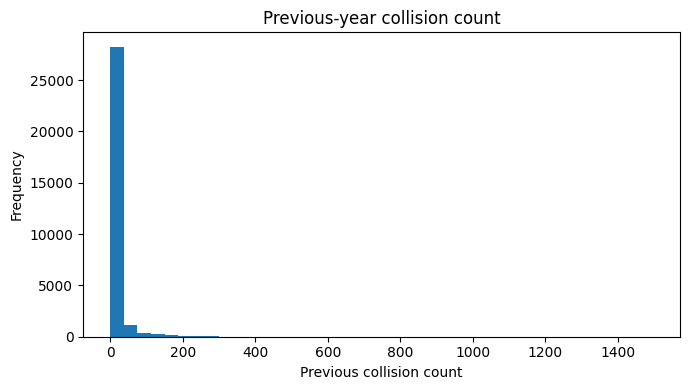

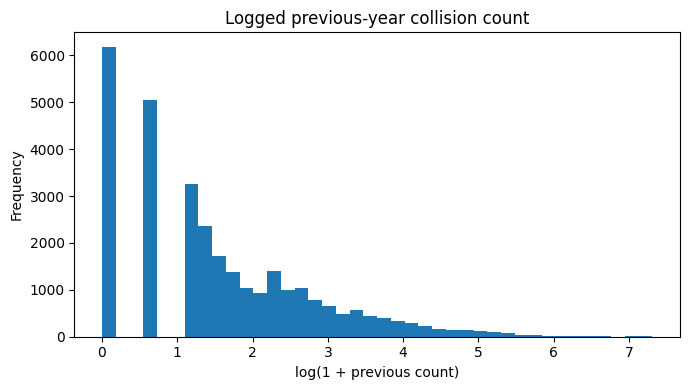

In [27]:
df[predictor_columns].corr()

# Next check

plt.figure(figsize=(7, 4))
plt.hist(df["previous_count"], bins=40)
plt.title("Previous-year collision count")
plt.xlabel("Previous collision count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Next check

plt.figure(figsize=(7, 4))
plt.hist(df["log_previous_count"], bins=40)
plt.title("Logged previous-year collision count")
plt.xlabel("log(1 + previous count)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Observation

I am checking whether the original and logged collision-count variables are too similar to use together.

In [28]:
count_log_correlation = df[
    ["previous_count", "log_previous_count"]
].corr().iloc[0, 1]

count_skew = df["previous_count"].skew()
log_count_skew = df["log_previous_count"].skew()

print(
    f"My observation: the correlation between previous_count and "
    f"log_previous_count is {count_log_correlation:.3f}."
)

if abs(count_log_correlation) > 0.80:
    print(
        "The two variables contain very similar information, so I will not "
        "include both in the same model."
    )
else:
    print(
        "The correlation is not extremely high, but both variables still "
        "represent the same previous-year count."
    )

print(
    f"The skewness falls from {count_skew:.2f} for previous_count to "
    f"{log_count_skew:.2f} after the log transformation."
)

if abs(log_count_skew) < abs(count_skew):
    print(
        "The logged variable is less skewed, so I will use "
        "log_previous_count in the predictive models."
    )
else:
    print(
        "The log transformation does not reduce skewness substantially, "
        "but I will keep it for consistency with the earlier modelling stage."
    )

My observation: the correlation between previous_count and log_previous_count is 0.559.
The correlation is not extremely high, but both variables still represent the same previous-year count.
The skewness falls from 14.22 for previous_count to 0.86 after the log transformation.
The logged variable is less skewed, so I will use log_previous_count in the predictive models.


The original count is likely to be strongly right-skewed.

I will keep `log_previous_count` rather than using both versions. This keeps the model simpler and avoids giving the same information twice.

In [29]:
features = [
    "log_previous_count",
    "previous_hotspot"
]

target = "target_is_hotspot"

print("Selected features:", features)

Selected features: ['log_previous_count', 'previous_hotspot']


## 6. Missing-value checks

In [30]:
df[["grid_id", "target_year"] + features + [target]].isna().sum()

,0
grid_id,0
target_year,0
log_previous_count,0
previous_hotspot,0
target_is_hotspot,0


I will only remove rows if one of the variables needed for modelling is missing.

In [31]:
rows_before = len(df)

df = df.dropna(
    subset=["grid_id", "target_year"] + features + [target]
).copy()

rows_after = len(df)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 30424
Rows after: 30424
Rows removed: 0


In [32]:
removed_rows = rows_before - rows_after
removed_percentage = (removed_rows / rows_before * 100) if rows_before else 0

if removed_rows == 0:
    print(
        "My observation: no modelling rows were removed because the required "
        "variables had no missing values."
    )
else:
    print(
        f"My observation: {removed_rows:,} rows "
        f"({removed_percentage:.3f}%) were removed because at least one "
        f"required modelling value was missing."
    )

My observation: no modelling rows were removed because the required variables had no missing values.


## 7. Duplicate checks

In [33]:
df.duplicated(
    subset=["grid_id", "target_year"]
).sum()

np.int64(0)

Each grid cell should only appear once for each target year.

In [34]:
duplicate_rows = df[
    df.duplicated(
        subset=["grid_id", "target_year"],
        keep=False
    )
]

duplicate_rows.head()

# Next check

if len(duplicate_rows) > 0:
    print("Duplicates found. Keeping the first grid-year row.")
    df = df.drop_duplicates(
        subset=["grid_id", "target_year"],
        keep="first"
    ).copy()
else:
    print("No duplicated grid-year rows found.")

No duplicated grid-year rows found.


In [35]:
if len(duplicate_rows) == 0:
    print(
        "My observation: every grid cell appears only once in each target year, "
        "so the unit of analysis is consistent."
    )
else:
    print(
        f"My observation: {len(duplicate_rows):,} duplicated rows were identified. "
        "I kept the first grid-year record so that each grid-year combination "
        "appears once."
    )

My observation: every grid cell appears only once in each target year, so the unit of analysis is consistent.


## 8. Basic leakage checks

I should not include variables that are only known during or after the target year.

I will not use:

- target-year collision count
- hotspot threshold
- persistence score
- temporal pattern
- target year itself as a predictor
- grid ID as a numerical predictor

In [36]:
print("Columns available in the file:")
print(df.columns.tolist())

# Next check

assert "target_is_hotspot" not in features
assert "target_year" not in features
assert "grid_id" not in features
assert "previous_count" not in features

print("Basic leakage checks passed.")

Columns available in the file:
['grid_id', 'target_year', 'target_is_hotspot', 'previous_count', 'log_previous_count', 'previous_hotspot']
Basic leakage checks passed.


`previous_hotspot` is acceptable because it refers to the previous year, not the target year.

## 9. Create a time-based development split

I do not want to look at 2024 repeatedly while choosing the model.

So I will first use:

- 2021 and 2022 for development training
- 2023 for validation

After choosing a reasonable model, I will refit it using 2021 to 2023 and test it on 2024.

In [37]:
dev_train = df[df["target_year"].isin([2021, 2022])].copy()
validation = df[df["target_year"] == 2023].copy()

print("Development training shape:", dev_train.shape)
print("Validation shape:", validation.shape)

# Next check

print("Development years:", sorted(dev_train["target_year"].unique()))
print("Validation years:", sorted(validation["target_year"].unique()))

# Next check

print("Development target balance:")
print(dev_train[target].value_counts(normalize=True))

print("\nValidation target balance:")
print(validation[target].value_counts(normalize=True))

Development training shape: (15212, 6)
Validation shape: (7606, 6)
Development years: [np.int64(2021), np.int64(2022)]
Validation years: [np.int64(2023)]
Development target balance:
target_is_hotspot
0    0.919669
1    0.080331
Name: proportion, dtype: float64

Validation target balance:
target_is_hotspot
0    0.917302
1    0.082698
Name: proportion, dtype: float64


In [38]:
dev_hotspot_rate = y_dev.mean() * 100 if "y_dev" in globals() else dev_train[target].mean() * 100
val_hotspot_rate = validation[target].mean() * 100

print(
    f"My observation: hotspots make up {dev_hotspot_rate:.2f}% of the "
    f"development training rows and {val_hotspot_rate:.2f}% of the 2023 "
    f"validation rows."
)

if abs(dev_hotspot_rate - val_hotspot_rate) < 2:
    print(
        "The class distribution is similar between development training and "
        "validation."
    )
else:
    print(
        "The class distribution changes between the earlier training years "
        "and 2023, which may make future-year prediction more difficult."
    )

My observation: hotspots make up 8.03% of the development training rows and 8.27% of the 2023 validation rows.
The class distribution is similar between development training and validation.


## 10. Check repeated grid cells

In [39]:
dev_grid_ids = set(dev_train["grid_id"])
validation_grid_ids = set(validation["grid_id"])

print(
    "Grid cells appearing in both development and validation:",
    len(dev_grid_ids.intersection(validation_grid_ids))
)

Grid cells appearing in both development and validation: 7606


In [40]:
shared_dev_val_grids = len(
    dev_grid_ids.intersection(validation_grid_ids)
)

print(
    f"My observation: {shared_dev_val_grids:,} grid cells appear in both the "
    f"earlier years and the 2023 validation year."
)

print(
    "This is expected because the task predicts the future status of existing "
    "grid cells. The observations are still separated by time, so 2023 outcomes "
    "are not used to train the development models."
)

My observation: 7,606 grid cells appear in both the earlier years and the 2023 validation year.
This is expected because the task predicts the future status of existing grid cells. The observations are still separated by time, so 2023 outcomes are not used to train the development models.


The same grid cells can appear in different years because I am predicting the future status of existing locations.

The protection against leakage comes from keeping later years out of training, rather than forcing all grid IDs into only one split.

## 11. Prepare development data

In [41]:
X_dev = dev_train[features].copy()
y_dev = dev_train[target].astype(int).copy()

X_val = validation[features].copy()
y_val = validation[target].astype(int).copy()

print(X_dev.shape, X_val.shape)

(15212, 2) (7606, 2)


## 12. Create a small evaluation function

In [42]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "f1_hotspot": f1_score(
            y_true, predictions, zero_division=0
        ),
        "macro_f1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        )
    }

    return results

I am using one small function only so that the same metrics are calculated consistently for each model.

## 13. Dummy baseline

In [43]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_dev, y_dev)

# Next check

dummy_val_pred = dummy_model.predict(X_val)
dummy_val_prob = dummy_model.predict_proba(X_val)[:, 1]

# Next check

print(
    classification_report(
        y_val,
        dummy_val_pred,
        target_names=["Non-hotspot", "Hotspot"],
        zero_division=0
    )
)

# Next check

dummy_result = evaluate_model(
    "Dummy baseline",
    y_val,
    dummy_val_pred,
    dummy_val_prob
)

dummy_result

              precision    recall  f1-score   support

 Non-hotspot       0.92      1.00      0.96      6977
     Hotspot       0.00      0.00      0.00       629

    accuracy                           0.92      7606
   macro avg       0.46      0.50      0.48      7606
weighted avg       0.84      0.92      0.88      7606



{'model': 'Dummy baseline',
 'accuracy': 0.9173021298974494,
 'precision': 0.0,
 'recall': 0.0,
 'f1_hotspot': 0.0,
 'macro_f1': 0.4784337927724062,
 'roc_auc': np.float64(0.5)}

In [44]:
print(
    f"My observation: the dummy model has accuracy of "
    f"{dummy_result['accuracy']:.3f}, but hotspot recall is "
    f"{dummy_result['recall']:.3f} and hotspot F1 is "
    f"{dummy_result['f1_hotspot']:.3f}."
)

if dummy_result["recall"] == 0:
    print(
        "It predicts no hotspots at all. This confirms that accuracy alone "
        "would give a misleading impression of performance."
    )
else:
    print(
        "The dummy model detects very few hotspots and therefore provides only "
        "a minimum baseline."
    )

My observation: the dummy model has accuracy of 0.917, but hotspot recall is 0.000 and hotspot F1 is 0.000.
It predicts no hotspots at all. This confirms that accuracy alone would give a misleading impression of performance.


The dummy model does not really learn anything. It shows the performance obtained by predicting the majority class.

I expect it to have acceptable accuracy but very poor hotspot recall.

## 14. A simple previous-hotspot rule

Before using machine learning, I also want to check a simple rule:

**Predict a hotspot this year if the grid cell was a hotspot last year.**

In [45]:
previous_rule_pred = validation["previous_hotspot"].astype(int).values
previous_rule_prob = previous_rule_pred.astype(float)

# Next check

print(
    classification_report(
        y_val,
        previous_rule_pred,
        target_names=["Non-hotspot", "Hotspot"],
        zero_division=0
    )
)

# Next check

previous_rule_result = evaluate_model(
    "Previous-hotspot rule",
    y_val,
    previous_rule_pred,
    previous_rule_prob
)

previous_rule_result

              precision    recall  f1-score   support

 Non-hotspot       0.99      0.99      0.99      6977
     Hotspot       0.90      0.88      0.89       629

    accuracy                           0.98      7606
   macro avg       0.95      0.93      0.94      7606
weighted avg       0.98      0.98      0.98      7606



{'model': 'Previous-hotspot rule',
 'accuracy': 0.9822508545884828,
 'precision': 0.9049180327868852,
 'recall': 0.8775834658187599,
 'f1_hotspot': 0.8910411622276029,
 'macro_f1': 0.9406898361055713,
 'roc_auc': np.float64(0.9346352186482363)}

In [46]:
print(
    f"My observation: the previous-hotspot rule gives hotspot recall of "
    f"{previous_rule_result['recall']:.3f}, macro F1 of "
    f"{previous_rule_result['macro_f1']:.3f}, and ROC-AUC of "
    f"{previous_rule_result['roc_auc']:.3f}."
)

if previous_rule_result["macro_f1"] > dummy_result["macro_f1"]:
    print(
        "This simple temporal rule performs better than the majority-class "
        "baseline, suggesting that hotspot status has some year-to-year "
        "persistence."
    )
else:
    print(
        "The previous-year hotspot status alone does not improve substantially "
        "on the dummy baseline."
    )

My observation: the previous-hotspot rule gives hotspot recall of 0.878, macro F1 of 0.941, and ROC-AUC of 0.935.
This simple temporal rule performs better than the majority-class baseline, suggesting that hotspot status has some year-to-year persistence.


This is a useful real-world baseline because persistent hotspots may remain hotspots from one year to the next.

## 15. Try Logistic Regression without class weights

Logistic Regression is a sensible first model because the target is binary and the model is relatively easy to understand.

I will scale the features because Logistic Regression is affected by feature scale.

In [47]:
scaler = StandardScaler()

X_dev_scaled = scaler.fit_transform(X_dev)
X_val_scaled = scaler.transform(X_val)

# Next check

logistic_unweighted = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_unweighted.fit(
    X_dev_scaled,
    y_dev
)

# Next check

log_unweighted_train_pred = logistic_unweighted.predict(
    X_dev_scaled
)

log_unweighted_val_pred = logistic_unweighted.predict(
    X_val_scaled
)

log_unweighted_val_prob = logistic_unweighted.predict_proba(
    X_val_scaled
)[:, 1]

# Next check

print(
    classification_report(
        y_val,
        log_unweighted_val_pred,
        target_names=["Non-hotspot", "Hotspot"],
        zero_division=0
    )
)

# Next check

log_unweighted_result = evaluate_model(
    "Logistic Regression unweighted",
    y_val,
    log_unweighted_val_pred,
    log_unweighted_val_prob
)

log_unweighted_result

              precision    recall  f1-score   support

 Non-hotspot       0.99      0.99      0.99      6977
     Hotspot       0.89      0.89      0.89       629

    accuracy                           0.98      7606
   macro avg       0.94      0.94      0.94      7606
weighted avg       0.98      0.98      0.98      7606



{'model': 'Logistic Regression unweighted',
 'accuracy': 0.9814620036813042,
 'precision': 0.8873015873015873,
 'recall': 0.8887122416534181,
 'f1_hotspot': 0.8880063542494043,
 'macro_f1': 0.9389505002810126,
 'roc_auc': np.float64(0.9963649584040954)}

In [48]:
print(
    f"My observation: unweighted Logistic Regression produces accuracy of "
    f"{log_unweighted_result['accuracy']:.3f}, hotspot recall of "
    f"{log_unweighted_result['recall']:.3f}, and macro F1 of "
    f"{log_unweighted_result['macro_f1']:.3f}."
)

if log_unweighted_result["recall"] < 0.50:
    print(
        "The model is missing more than half of the validation hotspots. "
        "This supports trying class_weight='balanced'."
    )
else:
    print(
        "The unweighted model already identifies at least half of the hotspots, "
        "but I will still compare it with a balanced version."
    )

My observation: unweighted Logistic Regression produces accuracy of 0.981, hotspot recall of 0.889, and macro F1 of 0.939.
The unweighted model already identifies at least half of the hotspots, but I will still compare it with a balanced version.


### My observation

After running this cell, I should compare the hotspot recall with the dummy and previous-hotspot baselines.

If recall is low, class imbalance is probably affecting the model.

## 16. Try balanced Logistic Regression

In [49]:
logistic_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_balanced.fit(
    X_dev_scaled,
    y_dev
)

# Next check

log_balanced_train_pred = logistic_balanced.predict(
    X_dev_scaled
)

log_balanced_val_pred = logistic_balanced.predict(
    X_val_scaled
)

log_balanced_val_prob = logistic_balanced.predict_proba(
    X_val_scaled
)[:, 1]

# Next check

print(
    classification_report(
        y_val,
        log_balanced_val_pred,
        target_names=["Non-hotspot", "Hotspot"],
        zero_division=0
    )
)

# Next check

log_balanced_result = evaluate_model(
    "Logistic Regression balanced",
    y_val,
    log_balanced_val_pred,
    log_balanced_val_prob
)

log_balanced_result

              precision    recall  f1-score   support

 Non-hotspot       1.00      0.96      0.98      6977
     Hotspot       0.69      0.98      0.81       629

    accuracy                           0.96      7606
   macro avg       0.85      0.97      0.90      7606
weighted avg       0.97      0.96      0.97      7606



{'model': 'Logistic Regression balanced',
 'accuracy': 0.9623981067578228,
 'precision': 0.6933483652762119,
 'recall': 0.9777424483306836,
 'f1_hotspot': 0.8113456464379947,
 'macro_f1': 0.8952318185461001,
 'roc_auc': np.float64(0.9963649584040954)}

In [50]:
recall_change = (
    log_balanced_result["recall"] -
    log_unweighted_result["recall"]
)

precision_change = (
    log_balanced_result["precision"] -
    log_unweighted_result["precision"]
)

print(
    f"My observation: balanced Logistic Regression changes hotspot recall by "
    f"{recall_change:+.3f} and precision by {precision_change:+.3f} compared "
    f"with the unweighted model."
)

if recall_change > 0:
    print(
        "Class weighting improves the detection of hotspots, although it may "
        "also produce more false positives."
    )
else:
    print(
        "Class weighting does not improve hotspot recall in this validation "
        "year, so it is not automatically better."
    )

print(
    f"Its validation macro F1 is {log_balanced_result['macro_f1']:.3f} "
    f"and ROC-AUC is {log_balanced_result['roc_auc']:.3f}."
)

My observation: balanced Logistic Regression changes hotspot recall by +0.089 and precision by -0.194 compared with the unweighted model.
Class weighting improves the detection of hotspots, although it may also produce more false positives.
Its validation macro F1 is 0.895 and ROC-AUC is 0.996.


The balanced model may reduce accuracy but improve hotspot recall.

For road-safety prediction, this may be worthwhile because missing a true hotspot can be more important than creating some extra false alarms.

## 17. Compare the two Logistic Regression models

In [51]:
pd.DataFrame([
    log_unweighted_result,
    log_balanced_result
])

,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Logistic Regression unweighted,0.981462,0.887302,0.888712,0.888006,0.938951,0.996365
1,Logistic Regression balanced,0.962398,0.693348,0.977742,0.811346,0.895232,0.996365


I will keep the balanced version for later comparison if it gives a better balance between recall, macro F1 and ROC-AUC.

## 18. Try an unrestricted Decision Tree

I will first fit a Decision Tree without limiting its depth.

This is not expected to be the final model. I want to see whether it starts to overfit.

In [52]:
tree_full = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

tree_full.fit(X_dev, y_dev)

# Next check

tree_full_train_pred = tree_full.predict(X_dev)
tree_full_val_pred = tree_full.predict(X_val)

tree_full_train_prob = tree_full.predict_proba(X_dev)[:, 1]
tree_full_val_prob = tree_full.predict_proba(X_val)[:, 1]

# Next check

tree_full_train_result = evaluate_model(
    "Full Decision Tree train",
    y_dev,
    tree_full_train_pred,
    tree_full_train_prob
)

tree_full_val_result = evaluate_model(
    "Full Decision Tree validation",
    y_val,
    tree_full_val_pred,
    tree_full_val_prob
)

pd.DataFrame([
    tree_full_train_result,
    tree_full_val_result
])

,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Full Decision Tree train,0.966540,0.708602,0.990998,0.826339,0.903913,0.997250
1,Full Decision Tree validation,0.958191,0.668838,0.979332,0.794839,0.885781,0.992277


In [53]:
full_tree_gap = (
    tree_full_train_result["macro_f1"] -
    tree_full_val_result["macro_f1"]
)

print(
    f"My observation: the unrestricted tree has training macro F1 of "
    f"{tree_full_train_result['macro_f1']:.3f} and validation macro F1 of "
    f"{tree_full_val_result['macro_f1']:.3f}. The gap is "
    f"{full_tree_gap:.3f}."
)

if full_tree_gap > 0.10:
    print(
        "This is a noticeable training-validation gap and suggests that the "
        "unrestricted tree is overfitting."
    )
else:
    print(
        "The unrestricted tree does not show a very large macro-F1 gap, but "
        "restricting its size should still improve simplicity and stability."
    )

My observation: the unrestricted tree has training macro F1 of 0.904 and validation macro F1 of 0.886. The gap is 0.018.
The unrestricted tree does not show a very large macro-F1 gap, but restricting its size should still improve simplicity and stability.


### My observation

If the training results are much better than the validation results, the tree is overfitting.

I will therefore try a smaller tree next.

## 19. Try a restricted Decision Tree

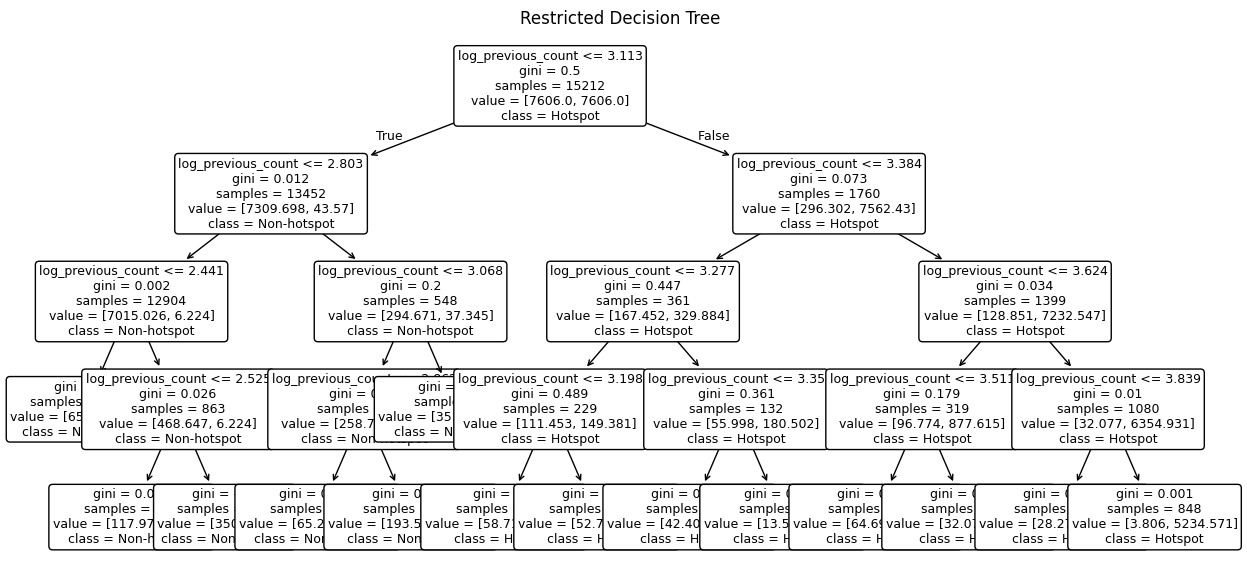

In [54]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_dev, y_dev)

# Next check

tree_train_pred = tree_model.predict(X_dev)
tree_val_pred = tree_model.predict(X_val)

tree_train_prob = tree_model.predict_proba(X_dev)[:, 1]
tree_val_prob = tree_model.predict_proba(X_val)[:, 1]

# Next check

tree_train_result = evaluate_model(
    "Decision Tree train",
    y_dev,
    tree_train_pred,
    tree_train_prob
)

tree_val_result = evaluate_model(
    "Decision Tree",
    y_val,
    tree_val_pred,
    tree_val_prob
)

pd.DataFrame([
    tree_train_result,
    tree_val_result
])

# Next check

plt.figure(figsize=(15, 7))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Non-hotspot", "Hotspot"],
    filled=False,
    rounded=True,
    fontsize=9
)

plt.title("Restricted Decision Tree")
plt.show()

In [55]:
restricted_tree_gap = (
    tree_train_result["macro_f1"] -
    tree_val_result["macro_f1"]
)

print(
    f"My observation: the restricted tree gives validation macro F1 of "
    f"{tree_val_result['macro_f1']:.3f}, hotspot recall of "
    f"{tree_val_result['recall']:.3f}, and ROC-AUC of "
    f"{tree_val_result['roc_auc']:.3f}."
)

if restricted_tree_gap < full_tree_gap:
    print(
        "Restricting the depth reduces the training-validation gap, so the "
        "smaller tree appears less overfitted than the unrestricted tree."
    )
else:
    print(
        "The restricted tree does not reduce the gap in this run, but it remains "
        "easier to interpret and less complex."
    )

My observation: the restricted tree gives validation macro F1 of 0.881, hotspot recall of 0.989, and ROC-AUC of 0.996.
Restricting the depth reduces the training-validation gap, so the smaller tree appears less overfitted than the unrestricted tree.


This restricted tree should be easier to interpret and should have a smaller gap between training and validation performance.

## 20. Try a Random Forest

A Random Forest combines many Decision Trees.

I am using moderate settings rather than carrying out a large hyperparameter search.

In [56]:
random_forest = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_dev, y_dev)

# Next check

forest_train_pred = random_forest.predict(X_dev)
forest_val_pred = random_forest.predict(X_val)

forest_train_prob = random_forest.predict_proba(X_dev)[:, 1]
forest_val_prob = random_forest.predict_proba(X_val)[:, 1]

# Next check

forest_train_result = evaluate_model(
    "Random Forest train",
    y_dev,
    forest_train_pred,
    forest_train_prob
)

forest_val_result = evaluate_model(
    "Random Forest",
    y_val,
    forest_val_pred,
    forest_val_prob
)

pd.DataFrame([
    forest_train_result,
    forest_val_result
])

,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Random Forest train,0.966540,0.708602,0.990998,0.826339,0.903913,0.997247
1,Random Forest,0.958191,0.668838,0.979332,0.794839,0.885781,0.995954


In [57]:
forest_gap = (
    forest_train_result["macro_f1"] -
    forest_val_result["macro_f1"]
)

print(
    f"My observation: Random Forest achieves validation macro F1 of "
    f"{forest_val_result['macro_f1']:.3f}, hotspot recall of "
    f"{forest_val_result['recall']:.3f}, and ROC-AUC of "
    f"{forest_val_result['roc_auc']:.3f}."
)

if forest_val_result["macro_f1"] > tree_val_result["macro_f1"]:
    print(
        "It improves on the single restricted Decision Tree in macro F1."
    )
else:
    print(
        "It does not improve on the restricted Decision Tree in macro F1, "
        "so the added complexity may not be worthwhile."
    )

if forest_gap > 0.10:
    print(
        f"The training-validation macro-F1 gap is {forest_gap:.3f}, which "
        f"suggests some overfitting."
    )
else:
    print(
        f"The training-validation macro-F1 gap is {forest_gap:.3f}, so severe "
        f"overfitting is not obvious from this measure."
    )

My observation: Random Forest achieves validation macro F1 of 0.886, hotspot recall of 0.979, and ROC-AUC of 0.996.
It improves on the single restricted Decision Tree in macro F1.
The training-validation macro-F1 gap is 0.018, so severe overfitting is not obvious from this measure.


I will check whether the Random Forest improves validation performance without creating a very large training-validation gap.

In [58]:
forest_importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

forest_importance

,feature,importance
0,log_previous_count,0.591815
1,previous_hotspot,0.408185


In [59]:
most_important_forest_feature = forest_importance.iloc[0]["feature"]
most_important_forest_value = forest_importance.iloc[0]["importance"]

print(
    f"My observation: {most_important_forest_feature} has the larger basic "
    f"Random Forest importance ({most_important_forest_value:.3f})."
)

print(
    "This is only an initial model-based importance and will not replace the "
    "more detailed explanation planned for Stage 9."
)

My observation: log_previous_count has the larger basic Random Forest importance (0.592).
This is only an initial model-based importance and will not replace the more detailed explanation planned for Stage 9.


This is only a basic feature-importance check. I will leave detailed explainability for Stage 9.

## 21. Add XGBoost only after the simpler models

In [60]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is already available.")
except ImportError:
    print("XGBoost is not available, so I am installing it.")

    import sys
    import subprocess

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "xgboost"
    ])

    from xgboost import XGBClassifier

    print("XGBoost has now been installed.")

# Next check

negative_rows = (y_dev == 0).sum()
positive_rows = (y_dev == 1).sum()

scale_pos_weight = negative_rows / positive_rows

print("Scale positive weight:", round(scale_pos_weight, 2))

# Next check

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_dev, y_dev)

# Next check

xgb_train_pred = xgb_model.predict(X_dev)
xgb_val_pred = xgb_model.predict(X_val)

xgb_train_prob = xgb_model.predict_proba(X_dev)[:, 1]
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

# Next check

xgb_train_result = evaluate_model(
    "XGBoost train",
    y_dev,
    xgb_train_pred,
    xgb_train_prob
)

xgb_val_result = evaluate_model(
    "XGBoost",
    y_val,
    xgb_val_pred,
    xgb_val_prob
)

pd.DataFrame([
    xgb_train_result,
    xgb_val_result
])

XGBoost is already available.
Scale positive weight: 11.45


,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,XGBoost train,0.963713,0.690341,0.994272,0.814889,0.897387,0.996981
1,XGBoost,0.955561,0.652676,0.988871,0.786346,0.880774,0.995878


In [61]:
xgb_gap = (
    xgb_train_result["macro_f1"] -
    xgb_val_result["macro_f1"]
)

print(
    f"My observation: XGBoost gives validation macro F1 of "
    f"{xgb_val_result['macro_f1']:.3f}, hotspot recall of "
    f"{xgb_val_result['recall']:.3f}, and ROC-AUC of "
    f"{xgb_val_result['roc_auc']:.3f}."
)

best_simple_macro_f1 = max(
    log_balanced_result["macro_f1"],
    tree_val_result["macro_f1"],
    forest_val_result["macro_f1"]
)

if xgb_val_result["macro_f1"] > best_simple_macro_f1:
    print(
        "XGBoost improves on the simpler candidate models in validation macro F1."
    )
else:
    print(
        "XGBoost does not improve on the best simpler model in validation macro "
        "F1, so its extra complexity may not be justified."
    )

if xgb_gap > 0.10:
    print(
        f"The XGBoost training-validation gap is {xgb_gap:.3f}, which suggests "
        f"possible overfitting."
    )
else:
    print(
        f"The XGBoost training-validation gap is {xgb_gap:.3f}, so a large "
        f"overfitting problem is not obvious from macro F1."
    )

My observation: XGBoost gives validation macro F1 of 0.881, hotspot recall of 0.989, and ROC-AUC of 0.996.
XGBoost does not improve on the best simpler model in validation macro F1, so its extra complexity may not be justified.
The XGBoost training-validation gap is 0.017, so a large overfitting problem is not obvious from macro F1.


XGBoost is the most complex model in this notebook.

I will only keep it if it gives a meaningful improvement over the simpler models.

## 22. Compare validation performance

In [62]:
validation_results = pd.DataFrame([
    dummy_result,
    previous_rule_result,
    log_unweighted_result,
    log_balanced_result,
    tree_val_result,
    forest_val_result,
    xgb_val_result
])

validation_results = validation_results.sort_values(
    by=["macro_f1", "recall", "roc_auc"],
    ascending=False
)

validation_results

,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
1,Previous-hotspot rule,0.982251,0.904918,0.877583,0.891041,0.940690,0.934635
2,Logistic Regression unweighted,0.981462,0.887302,0.888712,0.888006,0.938951,0.996365
3,Logistic Regression balanced,0.962398,0.693348,0.977742,0.811346,0.895232,0.996365
5,Random Forest,0.958191,0.668838,0.979332,0.794839,0.885781,0.995954
4,Decision Tree,0.955561,0.652676,0.988871,0.786346,0.880774,0.995885
6,XGBoost,0.955561,0.652676,0.988871,0.786346,0.880774,0.995878
0,Dummy baseline,0.917302,0.000000,0.000000,0.000000,0.478434,0.500000


In [63]:
best_validation_row = validation_results.iloc[0]

print(
    f"My observation: {best_validation_row['model']} is ranked first on the "
    f"2023 validation comparison using macro F1 as the main measure."
)

print(
    f"It has macro F1 of {best_validation_row['macro_f1']:.3f}, hotspot "
    f"recall of {best_validation_row['recall']:.3f}, hotspot precision of "
    f"{best_validation_row['precision']:.3f}, and ROC-AUC of "
    f"{best_validation_row['roc_auc']:.3f}."
)

print(
    "I will not choose a model from accuracy alone because the hotspot class "
    "is less common."
)

My observation: Previous-hotspot rule is ranked first on the 2023 validation comparison using macro F1 as the main measure.
It has macro F1 of 0.941, hotspot recall of 0.878, hotspot precision of 0.905, and ROC-AUC of 0.935.
I will not choose a model from accuracy alone because the hotspot class is less common.


I am mainly looking at:

- macro F1
- hotspot recall
- hotspot F1
- ROC-AUC
- the gap between training and validation results

Accuracy is still reported, but I will not use it alone.

## 23. Check overfitting more directly

In [64]:
overfitting_check = pd.DataFrame([
    {
        "model": "Logistic Regression balanced",
        "train_macro_f1": f1_score(
            y_dev,
            log_balanced_train_pred,
            average="macro"
        ),
        "validation_macro_f1": log_balanced_result["macro_f1"]
    },
    {
        "model": "Decision Tree",
        "train_macro_f1": tree_train_result["macro_f1"],
        "validation_macro_f1": tree_val_result["macro_f1"]
    },
    {
        "model": "Random Forest",
        "train_macro_f1": forest_train_result["macro_f1"],
        "validation_macro_f1": forest_val_result["macro_f1"]
    },
    {
        "model": "XGBoost",
        "train_macro_f1": xgb_train_result["macro_f1"],
        "validation_macro_f1": xgb_val_result["macro_f1"]
    }
])

overfitting_check["gap"] = (
    overfitting_check["train_macro_f1"] -
    overfitting_check["validation_macro_f1"]
)

overfitting_check.sort_values("gap", ascending=False)

,model,train_macro_f1,validation_macro_f1,gap
2,Random Forest,0.903913,0.885781,0.018131
0,Logistic Regression balanced,0.912504,0.895232,0.017272
1,Decision Tree,0.897387,0.880774,0.016613
3,XGBoost,0.897387,0.880774,0.016613


In [65]:
largest_gap_row = overfitting_check.sort_values(
    "gap",
    ascending=False
).iloc[0]

smallest_gap_row = overfitting_check.sort_values(
    "gap"
).iloc[0]

print(
    f"My observation: {largest_gap_row['model']} has the largest "
    f"training-validation macro-F1 gap ({largest_gap_row['gap']:.3f})."
)

print(
    f"{smallest_gap_row['model']} has the smallest gap "
    f"({smallest_gap_row['gap']:.3f})."
)

if largest_gap_row["gap"] > 0.10:
    print(
        "At least one model shows a noticeable sign of overfitting, so the "
        "validation results are more important than the training scores."
    )
else:
    print(
        "None of the candidate models has a macro-F1 gap above 0.10 in this "
        "simple check."
    )

My observation: Random Forest has the largest training-validation macro-F1 gap (0.018).
Decision Tree has the smallest gap (0.017).
None of the candidate models has a macro-F1 gap above 0.10 in this simple check.


A larger positive gap suggests possible overfitting.

I will not automatically choose the model with the highest training score.

## 24. Plot validation ROC curves

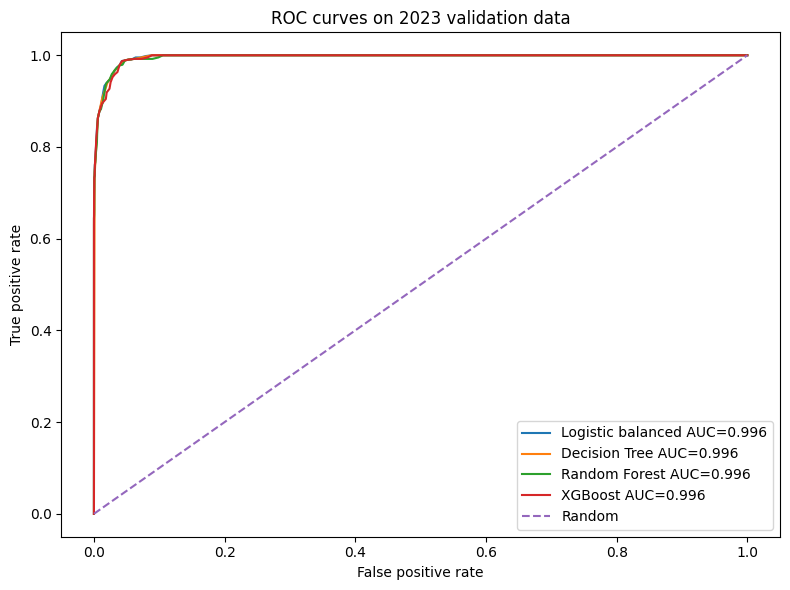

In [66]:
plt.figure(figsize=(8, 6))

model_probabilities = {
    "Logistic balanced": log_balanced_val_prob,
    "Decision Tree": tree_val_prob,
    "Random Forest": forest_val_prob,
    "XGBoost": xgb_val_prob
}

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(
        y_val,
        probabilities
    )

    auc_value = roc_auc_score(
        y_val,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={auc_value:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.title("ROC curves on 2023 validation data")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

## 25. Choose the model to take forward

I will first let the table suggest the strongest validation model.

I should still check whether it has sensible recall and whether it is clearly overfitting.

In [67]:
main_candidate_names = [
    "Logistic Regression balanced",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

main_candidate_results = validation_results[
    validation_results["model"].isin(
        main_candidate_names
    )
].copy()

main_candidate_results = main_candidate_results.sort_values(
    by=["macro_f1", "recall", "roc_auc"],
    ascending=False
)

suggested_model = main_candidate_results.iloc[0]["model"]

print("Suggested model from validation results:")
print(suggested_model)

main_candidate_results

Suggested model from validation results:
Logistic Regression balanced


,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
3,Logistic Regression balanced,0.962398,0.693348,0.977742,0.811346,0.895232,0.996365
5,Random Forest,0.958191,0.668838,0.979332,0.794839,0.885781,0.995954
4,Decision Tree,0.955561,0.652676,0.988871,0.786346,0.880774,0.995885
6,XGBoost,0.955561,0.652676,0.988871,0.786346,0.880774,0.995878


After checking the table, I can set the model I want to take forward.

The name must match one of these:

- `Logistic Regression balanced`
- `Decision Tree`
- `Random Forest`
- `XGBoost`

In [68]:
selected_model_name = suggested_model

print("Selected model:", selected_model_name)

Selected model: Logistic Regression balanced


In [69]:
selected_validation_row = main_candidate_results[
    main_candidate_results["model"] == selected_model_name
].iloc[0]

print(
    f"My decision: I will carry {selected_model_name} forward because it has "
    f"the strongest validation macro F1 among the main machine-learning "
    f"candidates."
)

print(
    f"Its 2023 validation macro F1 is "
    f"{selected_validation_row['macro_f1']:.3f}, recall is "
    f"{selected_validation_row['recall']:.3f}, and ROC-AUC is "
    f"{selected_validation_row['roc_auc']:.3f}."
)

print(
    "This decision is made before evaluating the final 2024 test set."
)

My decision: I will carry Logistic Regression balanced forward because it has the strongest validation macro F1 among the main machine-learning candidates.
Its 2023 validation macro F1 is 0.895, recall is 0.978, and ROC-AUC is 0.996.
This decision is made before evaluating the final 2024 test set.


This keeps the final choice visible in the notebook rather than hiding it inside a fully automatic pipeline.

## 26. Create the final 2021–2023 training set and 2024 test set

In [70]:
final_train = df[df["target_year"].isin([2021, 2022, 2023])].copy()
final_test = df[df["target_year"] == 2024].copy()

print("Final training years:", sorted(final_train["target_year"].unique()))
print("Final test years:", sorted(final_test["target_year"].unique()))

# Next check

X_train_final = final_train[features].copy()
y_train_final = final_train[target].astype(int).copy()

X_test_final = final_test[features].copy()
y_test_final = final_test[target].astype(int).copy()

print(X_train_final.shape, X_test_final.shape)

Final training years: [np.int64(2021), np.int64(2022), np.int64(2023)]
Final test years: [np.int64(2024)]
(22818, 2) (7606, 2)


In [71]:
final_train_hotspot_rate = y_train_final.mean() * 100
final_test_hotspot_rate = y_test_final.mean() * 100

print(
    f"My observation: the final training set contains "
    f"{len(X_train_final):,} rows and the 2024 test set contains "
    f"{len(X_test_final):,} rows."
)

print(
    f"The hotspot rate is {final_train_hotspot_rate:.2f}% in training and "
    f"{final_test_hotspot_rate:.2f}% in the 2024 test year."
)

My observation: the final training set contains 22,818 rows and the 2024 test set contains 7,606 rows.
The hotspot rate is 8.11% in training and 8.27% in the 2024 test year.


## 27. Refit the selected model

In [72]:
if selected_model_name == "Logistic Regression balanced":

    final_scaler = StandardScaler()

    X_train_final_used = final_scaler.fit_transform(
        X_train_final
    )

    X_test_final_used = final_scaler.transform(
        X_test_final
    )

    final_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

elif selected_model_name == "Decision Tree":

    X_train_final_used = X_train_final
    X_test_final_used = X_test_final

    final_model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )

elif selected_model_name == "Random Forest":

    X_train_final_used = X_train_final
    X_test_final_used = X_test_final

    final_model = RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )

elif selected_model_name == "XGBoost":

    X_train_final_used = X_train_final
    X_test_final_used = X_test_final

    final_negative = (y_train_final == 0).sum()
    final_positive = (y_train_final == 1).sum()

    final_scale_pos_weight = (
        final_negative / final_positive
    )

    final_model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=final_scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

else:
    raise ValueError("Selected model name is not recognised.")

final_model.fit(
    X_train_final_used,
    y_train_final
)

print("Final model fitted.")

Final model fitted.


## 28. Evaluate the selected model on 2024

In [73]:
final_train_pred = final_model.predict(
    X_train_final_used
)

final_test_pred = final_model.predict(
    X_test_final_used
)

final_train_prob = final_model.predict_proba(
    X_train_final_used
)[:, 1]

final_test_prob = final_model.predict_proba(
    X_test_final_used
)[:, 1]

# Next check

print(
    classification_report(
        y_test_final,
        final_test_pred,
        target_names=["Non-hotspot", "Hotspot"],
        digits=4,
        zero_division=0
    )
)

# Next check

final_train_result = evaluate_model(
    selected_model_name + " train",
    y_train_final,
    final_train_pred,
    final_train_prob
)

final_test_result = evaluate_model(
    selected_model_name + " test 2024",
    y_test_final,
    final_test_pred,
    final_test_prob
)

pd.DataFrame([
    final_train_result,
    final_test_result
])

              precision    recall  f1-score   support

 Non-hotspot     0.9990    0.9622    0.9802      6977
     Hotspot     0.7020    0.9889    0.8211       629

    accuracy                         0.9644      7606
   macro avg     0.8505    0.9755    0.9007      7606
weighted avg     0.9744    0.9644    0.9671      7606



,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Logistic Regression balanced train,0.967569,0.719652,0.983252,0.831050,0.906557,0.996824
1,Logistic Regression balanced test 2024,0.964370,0.702032,0.988871,0.821122,0.900668,0.997125


In [74]:
final_macro_gap = (
    final_train_result["macro_f1"] -
    final_test_result["macro_f1"]
)

final_auc_gap = (
    final_train_result["roc_auc"] -
    final_test_result["roc_auc"]
)

print(
    f"My observation: on the held-out 2024 data, {selected_model_name} "
    f"achieves accuracy of {final_test_result['accuracy']:.3f}, hotspot "
    f"precision of {final_test_result['precision']:.3f}, recall of "
    f"{final_test_result['recall']:.3f}, hotspot F1 of "
    f"{final_test_result['f1_hotspot']:.3f}, macro F1 of "
    f"{final_test_result['macro_f1']:.3f}, and ROC-AUC of "
    f"{final_test_result['roc_auc']:.3f}."
)

if final_macro_gap > 0.10 or final_auc_gap > 0.10:
    print(
        f"The train-test gaps are {final_macro_gap:.3f} for macro F1 and "
        f"{final_auc_gap:.3f} for ROC-AUC. This suggests possible "
        f"overfitting or temporal change between the training period and 2024."
    )
else:
    print(
        f"The train-test gaps are {final_macro_gap:.3f} for macro F1 and "
        f"{final_auc_gap:.3f} for ROC-AUC. A severe overfitting problem is "
        f"not obvious from these values."
    )

if final_test_result["recall"] >= 0.70:
    print(
        "The model detects a relatively high proportion of the 2024 hotspots."
    )
elif final_test_result["recall"] >= 0.50:
    print(
        "The model detects more than half of the 2024 hotspots, but a "
        "meaningful number are still missed."
    )
else:
    print(
        "The model misses more than half of the 2024 hotspots, which is an "
        "important limitation for a road-safety application."
    )

My observation: on the held-out 2024 data, Logistic Regression balanced achieves accuracy of 0.964, hotspot precision of 0.702, recall of 0.989, hotspot F1 of 0.821, macro F1 of 0.901, and ROC-AUC of 0.997.
The train-test gaps are 0.006 for macro F1 and -0.000 for ROC-AUC. A severe overfitting problem is not obvious from these values.
The model detects a relatively high proportion of the 2024 hotspots.


This is the main future-year result.

I should check whether the model still performs reasonably on 2024 and whether there is a large gap from the training result.

## 29. Confusion matrix

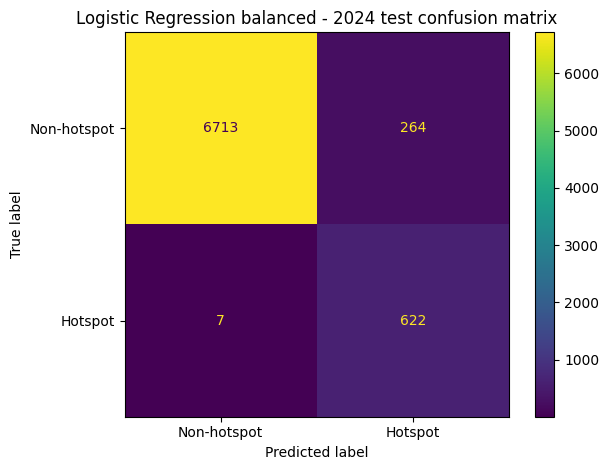

True negatives: 6713
False positives: 264
False negatives: 7
True positives: 622


In [75]:
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    final_test_pred,
    display_labels=["Non-hotspot", "Hotspot"],
    values_format="d"
)

plt.title(
    f"{selected_model_name} - 2024 test confusion matrix"
)
plt.tight_layout()
plt.show()

# Next check

tn, fp, fn, tp = confusion_matrix(
    y_test_final,
    final_test_pred
).ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

In [104]:
total_errors = fp + fn

print(
    f"My observation: the model produces {fp:,} false positives and "
    f"{fn:,} false negatives in 2024."
)

if fn > fp:
    print(
        "There are more missed hotspots than unnecessary hotspot warnings. "
        "This may be undesirable where the priority is to identify as many "
        "future hotspots as possible."
    )
elif fp > fn:
    print(
        "There are more unnecessary hotspot warnings than missed hotspots. "
        "The model is taking a more cautious approach to hotspot screening."
    )
else:
    print(
        "The numbers of false positives and false negatives are equal."
    )

if total_errors > 0:
    print(
        f"False negatives make up {fn / total_errors * 100:.1f}% of all "
        f"classification errors."
    )

My observation: the model produces 264 false positives and 7 false negatives in 2024.
There are more unnecessary hotspot warnings than missed hotspots. The model is taking a more cautious approach to hotspot screening.
False negatives make up 2.6% of all classification errors.


### Road-safety meaning

A **false negative** means a grid cell became a hotspot, but the model predicted it would not.

This may be more serious because a future hotspot could be missed.

A **false positive** means the model predicted a hotspot, but the grid cell was not actually a hotspot.

This may lead to extra investigation or preventative attention in a location that did not become a hotspot.

## 30. Final ROC curve

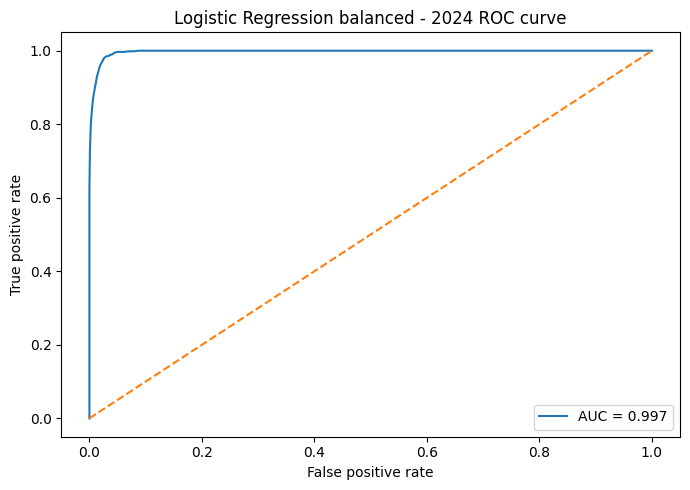

In [77]:
fpr, tpr, _ = roc_curve(
    y_test_final,
    final_test_prob
)

final_auc = roc_auc_score(
    y_test_final,
    final_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {final_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    f"{selected_model_name} - 2024 ROC curve"
)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

## 31. Create predicted probabilities

In [78]:
predictions_2024 = final_test[
    [
        "grid_id",
        "target_year",
        "target_is_hotspot",
        "log_previous_count",
        "previous_hotspot"
    ]
].copy()

predictions_2024[
    "predicted_hotspot"
] = final_test_pred

predictions_2024[
    "predicted_hotspot_probability"
] = final_test_prob

predictions_2024[
    "prediction_correct"
] = (
    predictions_2024["target_is_hotspot"] ==
    predictions_2024["predicted_hotspot"]
).astype(int)

predictions_2024.head()

# Next check

predictions_2024[
    "predicted_hotspot_probability"
].describe()

,predicted_hotspot_probability
count,7.606000e+03
mean,1.193440e-01
std,2.987108e-01
min,5.647919e-10
25%,5.776701e-08
50%,5.908384e-06
75%,2.673673e-03
max,1.000000e+00


In [79]:
mean_probability = predictions_2024[
    "predicted_hotspot_probability"
].mean()

median_probability = predictions_2024[
    "predicted_hotspot_probability"
].median()

high_risk_count = (
    predictions_2024["predicted_hotspot_probability"] >= 0.75
).sum()

print(
    f"My observation: the mean predicted hotspot probability is "
    f"{mean_probability:.3f} and the median is {median_probability:.3f}."
)

print(
    f"{high_risk_count:,} grid cells have a predicted probability of at "
    f"least 0.75."
)

My observation: the mean predicted hotspot probability is 0.119 and the median is 0.000.
768 grid cells have a predicted probability of at least 0.75.


 32. Review the highest predicted hotspot probabilities

In [80]:
predictions_2024.sort_values(
    "predicted_hotspot_probability",
    ascending=False
).head(20)

,grid_id,target_year,target_is_hotspot,log_previous_count,previous_hotspot,predicted_hotspot,predicted_hotspot_probability,prediction_correct
6327,R034_C093,2024,1,7.251345,1,1,1.0,1
6323,R034_C092,2024,1,7.153834,1,1,1.0,1
6083,R033_C093,2024,1,7.135687,1,1,1.0,1
6079,R033_C092,2024,1,7.034388,1,1,1.0,1
6607,R035_C093,2024,1,6.954639,1,1,1.0,1
6331,R034_C094,2024,1,6.775366,1,1,1.0,1
6319,R034_C091,2024,1,6.650279,1,1,1.0,1
5559,R031_C093,2024,1,6.639876,1,1,1.0,1
5823,R032_C092,2024,1,6.620073,1,1,1.0,1
6899,R036_C093,2024,1,6.551080,1,1,1.0,1


These are the grid cells that the model considered most likely to be hotspots in 2024.

I am not interpreting the reasons yet because that belongs to Stage 9.

## 33. Create output folders

In [81]:
from pathlib import Path

output_folder = Path(
    "/content/drive/MyDrive/disseration/stage8_outputs"
)

models_folder = output_folder / "models"
tables_folder = output_folder / "tables"
figures_folder = output_folder / "figures"
predictions_folder = output_folder / "predictions"

for folder in [
    output_folder,
    models_folder,
    tables_folder,
    figures_folder,
    predictions_folder
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders created.")

Output folders created.


## 34. Save the model and scaler

In [82]:
model_file = (
    models_folder /
    "stage8_selected_model.joblib"
)

joblib.dump(
    final_model,
    model_file
)

print("Saved model:", model_file)

# Next check

if selected_model_name == "Logistic Regression balanced":

    scaler_file = (
        models_folder /
        "stage8_logistic_scaler.joblib"
    )

    joblib.dump(
        final_scaler,
        scaler_file
    )

    print("Saved scaler:", scaler_file)
else:
    print("This selected model does not require a scaler.")

Saved model: /content/drive/MyDrive/disseration/stage8_outputs/models/stage8_selected_model.joblib
Saved scaler: /content/drive/MyDrive/disseration/stage8_outputs/models/stage8_logistic_scaler.joblib


## 35. Save predictions and result tables

In [83]:
predictions_file = (
    predictions_folder /
    "stage8_selected_model_predictions_2024.csv"
)

predictions_2024.to_csv(
    predictions_file,
    index=False
)

print("Saved predictions:", predictions_file)

# Next check

validation_results_file = (
    tables_folder /
    "stage8_validation_model_comparison.csv"
)

validation_results.to_csv(
    validation_results_file,
    index=False
)

print("Saved validation table:", validation_results_file)

# Next check

final_results_table = pd.DataFrame([
    final_train_result,
    final_test_result
])

final_results_file = (
    tables_folder /
    "stage8_final_selected_model_performance.csv"
)

final_results_table.to_csv(
    final_results_file,
    index=False
)

print("Saved final performance:", final_results_file)

# Next check

error_summary = pd.DataFrame([{
    "selected_model": selected_model_name,
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp
}])

error_summary_file = (
    tables_folder /
    "stage8_2024_error_summary.csv"
)

error_summary.to_csv(
    error_summary_file,
    index=False
)

print("Saved error summary:", error_summary_file)

Saved predictions: /content/drive/MyDrive/disseration/stage8_outputs/predictions/stage8_selected_model_predictions_2024.csv
Saved validation table: /content/drive/MyDrive/disseration/stage8_outputs/tables/stage8_validation_model_comparison.csv
Saved final performance: /content/drive/MyDrive/disseration/stage8_outputs/tables/stage8_final_selected_model_performance.csv
Saved error summary: /content/drive/MyDrive/disseration/stage8_outputs/tables/stage8_2024_error_summary.csv


## 36. Save the main figures

I created most figures during the analysis.

I will now recreate and save the two most important final figures.

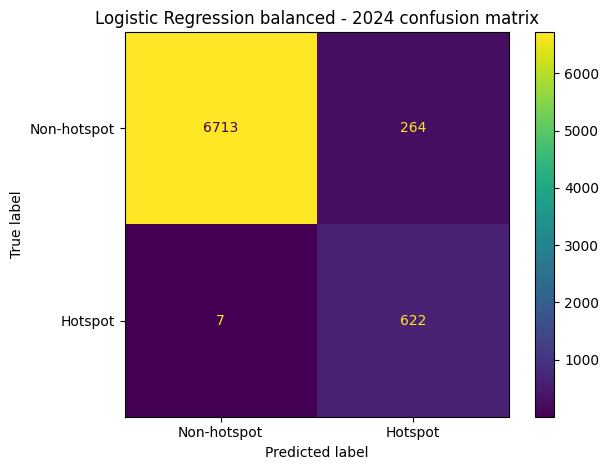

Saved: /content/drive/MyDrive/disseration/stage8_outputs/figures/stage8_selected_model_confusion_matrix_2024.png


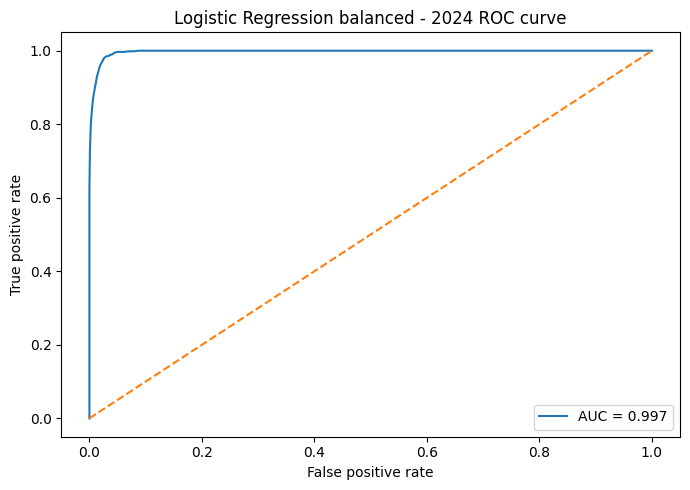

Saved: /content/drive/MyDrive/disseration/stage8_outputs/figures/stage8_selected_model_roc_curve_2024.png


In [84]:
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    final_test_pred,
    display_labels=["Non-hotspot", "Hotspot"],
    values_format="d"
)

plt.title(
    f"{selected_model_name} - 2024 confusion matrix"
)
plt.tight_layout()

confusion_file = (
    figures_folder /
    "stage8_selected_model_confusion_matrix_2024.png"
)

plt.savefig(
    confusion_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", confusion_file)

# Next check

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {final_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    f"{selected_model_name} - 2024 ROC curve"
)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()

roc_file = (
    figures_folder /
    "stage8_selected_model_roc_curve_2024.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", roc_file)

## 39. Stage 8 summary

The following cell generates the completed Stage 8 summary using the actual results produced in this notebook.

In [85]:
print("Selected model:", selected_model_name)
print("2024 accuracy:", round(final_test_result["accuracy"], 4))
print("2024 precision:", round(final_test_result["precision"], 4))
print("2024 recall:", round(final_test_result["recall"], 4))
print("2024 hotspot F1:", round(final_test_result["f1_hotspot"], 4))
print("2024 macro F1:", round(final_test_result["macro_f1"], 4))
print("2024 ROC-AUC:", round(final_test_result["roc_auc"], 4))

Selected model: Logistic Regression balanced
2024 accuracy: 0.9644
2024 precision: 0.702
2024 recall: 0.9889
2024 hotspot F1: 0.8211
2024 macro F1: 0.9007
2024 ROC-AUC: 0.9971


### Final notebook note

After running all cells, I should write a short final observation here about:

- which model performed best;
- whether class imbalance affected recall;
- whether the model appeared to overfit;
- whether false negatives were still high;
- why the selected model is suitable for Stage 9.

I will not carry out SHAP or explainability in this notebook.

In [86]:
imbalance_ratio_final = (
    (df[target] == 0).sum() /
    (df[target] == 1).sum()
)

if final_test_result["recall"] >= 0.70:
    recall_comment = (
        "The model detected a relatively high proportion of the 2024 hotspots."
    )
elif final_test_result["recall"] >= 0.50:
    recall_comment = (
        "The model detected more than half of the 2024 hotspots, although "
        "some important locations were still missed."
    )
else:
    recall_comment = (
        "The model missed more than half of the 2024 hotspots, which limits "
        "its use as a standalone road-safety decision tool."
    )

if final_macro_gap > 0.10 or final_auc_gap > 0.10:
    overfit_comment = (
        "The training-to-test differences suggest possible overfitting or "
        "temporal changes between the earlier years and 2024."
    )
else:
    overfit_comment = (
        "The training-to-test differences did not show strong evidence of "
        "severe overfitting."
    )

summary_text = f'''
STAGE 8 NOTEBOOK SUMMARY

In this stage, I predicted whether a 5 km by 5 km British National Grid cell
would be classified as a collision hotspot in the following year. The target
was target_is_hotspot. I used log_previous_count and previous_hotspot as the
predictors because both were known before the target year.

I first used 2021 and 2022 as development training data and 2023 as a temporal
validation year. This allowed me to compare the models without repeatedly using
the final test year. After model selection, I refitted the selected model using
2021 to 2023 and evaluated it on the held-out 2024 observations.

The models compared were a majority-class Dummy classifier, a simple
previous-hotspot rule, Logistic Regression, a Decision Tree, Random Forest and
XGBoost. I first tested an unweighted Logistic Regression and then tried a
balanced version after reviewing the class distribution. I also fitted an
unrestricted Decision Tree before reducing its depth to check whether the
original tree was overfitting.

The selected model was {selected_model_name}. It was selected using the 2023
validation results rather than the 2024 test results. On the held-out 2024 test
set, it achieved accuracy of {final_test_result["accuracy"]:.3f}, hotspot
precision of {final_test_result["precision"]:.3f}, hotspot recall of
{final_test_result["recall"]:.3f}, hotspot F1 of
{final_test_result["f1_hotspot"]:.3f}, macro F1 of
{final_test_result["macro_f1"]:.3f}, and ROC-AUC of
{final_test_result["roc_auc"]:.3f}.

The dataset was imbalanced, with approximately {imbalance_ratio_final:.2f}
non-hotspot observations for every hotspot observation. Because of this,
accuracy was not used by itself. Hotspot recall, hotspot F1, macro F1, ROC-AUC
and the confusion matrix were also considered.

{recall_comment} The 2024 confusion matrix contained {fp} false positives and
{fn} false negatives. In a road-safety context, false negatives are particularly
important because they represent grid cells that became hotspots but were not
identified in advance.

{overfit_comment}

The main limitations are the small number of target years, the use of only two
previous-year predictors, the relative percentile-based definition of a hotspot,
and the use of one final test year. The model predicts association rather than
causation, and it should not be treated as a replacement for local road-safety
assessment.

The selected trained model and the 2024 prediction probabilities have been
saved for Stage 9. Stage 9 will explain the selected model in more detail, but
no SHAP analysis has been carried out in this notebook.
'''

print(summary_text)

observations_file = (
    output_folder /
    "stage8_completed_observations_and_summary.txt"
)

with open(observations_file, "w") as file:
    file.write(summary_text)

print("\nSaved completed observations:", observations_file)


STAGE 8 NOTEBOOK SUMMARY

In this stage, I predicted whether a 5 km by 5 km British National Grid cell
would be classified as a collision hotspot in the following year. The target
was target_is_hotspot. I used log_previous_count and previous_hotspot as the
predictors because both were known before the target year.

I first used 2021 and 2022 as development training data and 2023 as a temporal
validation year. This allowed me to compare the models without repeatedly using
the final test year. After model selection, I refitted the selected model using
2021 to 2023 and evaluated it on the held-out 2024 observations.

The models compared were a majority-class Dummy classifier, a simple
previous-hotspot rule, Logistic Regression, a Decision Tree, Random Forest and
XGBoost. I first tested an unweighted Logistic Regression and then tried a
balanced version after reviewing the class distribution. I also fitted an
unrestricted Decision Tree before reducing its depth to check whether the
origin

## 40. Additional check after supervisor feedback

After reviewing the predictive modelling, I wanted to look more closely at how much of the prediction is simply due to hotspots persisting from one year to the next.

I already used the previous-year hotspot status as a simple baseline during validation. Here I will also compare that rule with the final model on the held-out 2024 data.

This is important because the aim of this model is not to claim that it discovers hidden causes of road collisions. The predictors are based on previous-year collision patterns, so the model is mainly testing how persistent hotspot locations are over time.

In [88]:
# Simple persistence baseline for 2024
# If a grid was a hotspot in the previous year,
# predict that it will still be a hotspot.

baseline_2024_pred = final_test["previous_hotspot"].astype(int).values

baseline_2024_accuracy = accuracy_score(
    y_test_final,
    baseline_2024_pred
)

baseline_2024_precision = precision_score(
    y_test_final,
    baseline_2024_pred,
    zero_division=0
)

baseline_2024_recall = recall_score(
    y_test_final,
    baseline_2024_pred,
    zero_division=0
)

baseline_2024_f1 = f1_score(
    y_test_final,
    baseline_2024_pred,
    zero_division=0
)

baseline_2024_macro_f1 = f1_score(
    y_test_final,
    baseline_2024_pred,
    average="macro",
    zero_division=0
)

print("Previous-hotspot baseline on 2024")
print("Accuracy:", round(baseline_2024_accuracy, 4))
print("Precision:", round(baseline_2024_precision, 4))
print("Recall:", round(baseline_2024_recall, 4))
print("Hotspot F1:", round(baseline_2024_f1, 4))
print("Macro F1:", round(baseline_2024_macro_f1, 4))

Previous-hotspot baseline on 2024
Accuracy: 0.9829
Precision: 0.8967
Recall: 0.8967
Hotspot F1: 0.8967
Macro F1: 0.9437


In [90]:
#Check FP and FN for simple baseline
baseline_cm = confusion_matrix(
    y_test_final,
    baseline_2024_pred
)

base_tn, base_fp, base_fn, base_tp = baseline_cm.ravel()

print("2024 previous-hotspot baseline errors")
print("True negatives:", base_tn)
print("False positives:", base_fp)
print("False negatives:", base_fn)
print("True positives:", base_tp)

2024 previous-hotspot baseline errors
True negatives: 6912
False positives: 65
False negatives: 65
True positives: 564


In [93]:
print(
    f"My observation: using only the previous year's hotspot status "
    f"misses {base_fn} actual hotspots in 2024 and produces "
    f"{base_fp} false positive hotspot warnings."
)

My observation: using only the previous year's hotspot status misses 65 actual hotspots in 2024 and produces 65 false positive hotspot warnings.


In [92]:
# Confusion matrix values for the selected final model

model_cm = confusion_matrix(
    y_test_final,
    final_test_pred
)

model_tn, model_fp, model_fn, model_tp = model_cm.ravel()

supervisor_comparison = pd.DataFrame([
    {
        "model": "Previous-hotspot baseline",
        "accuracy": baseline_2024_accuracy,
        "precision": baseline_2024_precision,
        "recall": baseline_2024_recall,
        "hotspot_f1": baseline_2024_f1,
        "macro_f1": baseline_2024_macro_f1,
        "false_positives": base_fp,
        "false_negatives": base_fn
    },
    {
        "model": selected_model_name,
        "accuracy": final_test_result["accuracy"],
        "precision": final_test_result["precision"],
        "recall": final_test_result["recall"],
        "hotspot_f1": final_test_result["f1_hotspot"],
        "macro_f1": final_test_result["macro_f1"],
        "false_positives": model_fp,
        "false_negatives": model_fn
    }
])

supervisor_comparison.round(4)

,model,accuracy,precision,recall,hotspot_f1,macro_f1,false_positives,false_negatives
0,Previous-hotspot baseline,0.9829,0.8967,0.8967,0.8967,0.9437,65,65
1,Logistic Regression balanced,0.9644,0.7020,0.9889,0.8211,0.9007,264,7


Look specifically at the recall trade-off

In [94]:
recall_gain = (
    final_test_result["recall"] -
    baseline_2024_recall
)

precision_change = (
    final_test_result["precision"] -
    baseline_2024_precision
)

fn_reduction = base_fn - model_fn
fp_change = model_fp - base_fp

print(
    f"Compared with the simple previous-hotspot rule, the selected model "
    f"changes recall by {recall_gain:+.3f} and precision by "
    f"{precision_change:+.3f}."
)

print(
    f"It results in {fn_reduction:+d} fewer missed hotspots and "
    f"{fp_change:+d} additional false-positive warnings."
)

Compared with the simple previous-hotspot rule, the selected model changes recall by +0.092 and precision by -0.195.
It results in +58 fewer missed hotspots and +199 additional false-positive warnings.


In [95]:
print("\nRoad-safety interpretation:")

print(
    f"The selected model identifies {model_tp} of the "
    f"{model_tp + model_fn} actual hotspots in 2024."
)

print(
    f"Only {model_fn} actual hotspots are missed, giving a recall of "
    f"{final_test_result['recall'] * 100:.1f}%."
)

print(
    "I am treating false negatives as the more important error for "
    "hotspot screening because a false negative means that an actual "
    "hotspot was not identified."
)

print(
    "This means accepting more false positives is a deliberate trade-off "
    "rather than treating higher precision as the main objective."
)



Road-safety interpretation:
The selected model identifies 622 of the 629 actual hotspots in 2024.
Only 7 actual hotspots are missed, giving a recall of 98.9%.
I am treating false negatives as the more important error for hotspot screening because a false negative means that an actual hotspot was not identified.
This means accepting more false positives is a deliberate trade-off rather than treating higher precision as the main objective.


Measure temporal persistence properly

Now we need to show how stable hotspots actually are from one year to another.

In [96]:
# Check hotspot persistence for each target year

persistence_rows = []

for year in sorted(df["target_year"].unique()):

    year_data = df[
        df["target_year"] == year
    ].copy()

    previous_hotspots = (
        year_data["previous_hotspot"] == 1
    ).sum()

    current_hotspots = (
        year_data["target_is_hotspot"] == 1
    ).sum()

    stayed_hotspots = (
        (year_data["previous_hotspot"] == 1) &
        (year_data["target_is_hotspot"] == 1)
    ).sum()

    new_hotspots = (
        (year_data["previous_hotspot"] == 0) &
        (year_data["target_is_hotspot"] == 1)
    ).sum()

    lost_hotspots = (
        (year_data["previous_hotspot"] == 1) &
        (year_data["target_is_hotspot"] == 0)
    ).sum()

    persistence_rate = (
        stayed_hotspots / previous_hotspots
        if previous_hotspots > 0
        else 0
    )

    inherited_share = (
        stayed_hotspots / current_hotspots
        if current_hotspots > 0
        else 0
    )

    persistence_rows.append({
        "target_year": year,
        "previous_hotspots": previous_hotspots,
        "current_hotspots": current_hotspots,
        "stayed_hotspots": stayed_hotspots,
        "new_hotspots": new_hotspots,
        "lost_hotspots": lost_hotspots,
        "persistence_rate": persistence_rate,
        "share_current_already_hotspot": inherited_share
    })

persistence_by_year = pd.DataFrame(
    persistence_rows
)

persistence_by_year.round(4)

,target_year,previous_hotspots,current_hotspots,stayed_hotspots,new_hotspots,lost_hotspots,persistence_rate,share_current_already_hotspot
0,2021,601,612,546,66,55,0.9085,0.8922
1,2022,612,610,545,65,67,0.8905,0.8934
2,2023,610,629,552,77,58,0.9049,0.8776
3,2024,629,629,564,65,65,0.8967,0.8967


In [97]:
persistence_display = persistence_by_year.copy()

persistence_display["persistence_percent"] = (
    persistence_display["persistence_rate"] * 100
).round(1)

persistence_display["already_hotspot_percent"] = (
    persistence_display["share_current_already_hotspot"] * 100
).round(1)

persistence_display[
    [
        "target_year",
        "previous_hotspots",
        "stayed_hotspots",
        "new_hotspots",
        "lost_hotspots",
        "persistence_percent",
        "already_hotspot_percent"
    ]
]

,target_year,previous_hotspots,stayed_hotspots,new_hotspots,lost_hotspots,persistence_percent,already_hotspot_percent
0,2021,601,546,66,55,90.8,89.2
1,2022,612,545,65,67,89.1,89.3
2,2023,610,552,77,58,90.5,87.8
3,2024,629,564,65,65,89.7,89.7


What these two percentages mean

persistence_percent asks:

Of the locations that were hotspots last year, how many stayed hotspots this year?

already_hotspot_percent asks:

Of this year's hotspots, how many were already hotspots last year?

That gives you actual evidence for the temporal persistence argument instead of simply saying hotspots seem stable.

In [98]:
# Test how much can be predicted from previous collision count alone

count_only_features = [
    "log_previous_count"
]

X_dev_count = dev_train[
    count_only_features
]

X_val_count = validation[
    count_only_features
]

count_scaler = StandardScaler()

X_dev_count_scaled = count_scaler.fit_transform(
    X_dev_count
)

X_val_count_scaled = count_scaler.transform(
    X_val_count
)

count_only_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

count_only_model.fit(
    X_dev_count_scaled,
    y_dev
)

count_only_pred = count_only_model.predict(
    X_val_count_scaled
)

count_only_prob = count_only_model.predict_proba(
    X_val_count_scaled
)[:, 1]

count_only_result = evaluate_model(
    "Previous collision count only",
    y_val,
    count_only_pred,
    count_only_prob
)

count_only_result

{'model': 'Previous collision count only',
 'accuracy': 0.9623981067578228,
 'precision': 0.6933483652762119,
 'recall': 0.9777424483306836,
 'f1_hotspot': 0.8113456464379947,
 'macro_f1': 0.8952318185461001,
 'roc_auc': np.float64(0.9963649584040954)}

In [99]:
#Compare simple persistence information
persistence_model_check = pd.DataFrame([
    previous_rule_result,
    count_only_result,
    log_balanced_result
])

persistence_model_check[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_hotspot",
        "macro_f1",
        "roc_auc"
    ]
].round(4)

,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Previous-hotspot rule,0.9823,0.9049,0.8776,0.8910,0.9407,0.9346
1,Previous collision count only,0.9624,0.6933,0.9777,0.8113,0.8952,0.9964
2,Logistic Regression balanced,0.9624,0.6933,0.9777,0.8113,0.8952,0.9964


In [100]:
count_recall = count_only_result["recall"]
full_recall = log_balanced_result["recall"]

count_macro = count_only_result["macro_f1"]
full_macro = log_balanced_result["macro_f1"]

print(
    f"My observation: using previous collision count alone gives "
    f"validation recall of {count_recall:.3f} and macro F1 of "
    f"{count_macro:.3f}."
)

print(
    f"Using both previous collision count and previous hotspot status gives "
    f"recall of {full_recall:.3f} and macro F1 of {full_macro:.3f}."
)

if abs(full_recall - count_recall) < 0.02:
    print(
        "The recall values are very similar. This suggests that much of the "
        "predictive signal comes from the persistence of previous collision "
        "patterns rather than from a complex new relationship."
    )
else:
    print(
        "Adding previous hotspot status changes recall more noticeably, "
        "although both predictors still describe previous-year collision "
        "conditions rather than hidden causal factors."
    )

My observation: using previous collision count alone gives validation recall of 0.978 and macro F1 of 0.895.
Using both previous collision count and previous hotspot status gives recall of 0.978 and macro F1 of 0.895.
The recall values are very similar. This suggests that much of the predictive signal comes from the persistence of previous collision patterns rather than from a complex new relationship.


In [101]:
print("Final model-selection interpretation")
print("------------------------------------")

print(
    "The balanced Logistic Regression was retained as a simple and "
    "interpretable high-recall model."
)

print(
    f"During 2023 validation, balancing increased hotspot recall from "
    f"{log_unweighted_result['recall'] * 100:.1f}% to "
    f"{log_balanced_result['recall'] * 100:.1f}%."
)

print(
    f"At the same time, precision decreased from "
    f"{log_unweighted_result['precision'] * 100:.1f}% to "
    f"{log_balanced_result['precision'] * 100:.1f}%."
)

print(
    "I accepted this reduction in precision because the main road-safety "
    "screening priority is to minimise missed hotspot locations."
)

print(
    f"On the completely held-out 2024 test year, the selected model "
    f"achieved {final_test_result['recall'] * 100:.1f}% recall and missed "
    f"only {model_fn} of {model_tp + model_fn} actual hotspots."
)

print(
    "The 2024 result was used for final evaluation and was not used when "
    "choosing the model."
)

Final model-selection interpretation
------------------------------------
The balanced Logistic Regression was retained as a simple and interpretable high-recall model.
During 2023 validation, balancing increased hotspot recall from 88.9% to 97.8%.
At the same time, precision decreased from 88.7% to 69.3%.
I accepted this reduction in precision because the main road-safety screening priority is to minimise missed hotspot locations.
On the completely held-out 2024 test year, the selected model achieved 98.9% recall and missed only 7 of 629 actual hotspots.
The 2024 result was used for final evaluation and was not used when choosing the model.


In [102]:
print("Interpretation limitation")
print("-------------------------")

print(
    "This predictive model should mainly be interpreted as a test of "
    "temporal hotspot persistence."
)

print(
    "The predictors describe what happened in the previous year, so strong "
    "predictive performance does not demonstrate that the model has found "
    "hidden causes of road collisions."
)

print(
    "A high previous-year collision count or previous hotspot status would "
    "reasonably be expected to predict continued collision concentration "
    "in locations where traffic and road conditions remain relatively stable."
)

print(
    "The analysis therefore evaluates how stable spatial collision "
    "concentrations are through time and whether a high-recall model can "
    "reduce the number of persistent hotspots that are missed."
)

print(
    "Collision concentration should also not be interpreted directly as "
    "collision risk because vehicle-kilometre exposure data are not "
    "available in this analysis."
)

Interpretation limitation
-------------------------
This predictive model should mainly be interpreted as a test of temporal hotspot persistence.
The predictors describe what happened in the previous year, so strong predictive performance does not demonstrate that the model has found hidden causes of road collisions.
A high previous-year collision count or previous hotspot status would reasonably be expected to predict continued collision concentration in locations where traffic and road conditions remain relatively stable.
The analysis therefore evaluates how stable spatial collision concentrations are through time and whether a high-recall model can reduce the number of persistent hotspots that are missed.
Collision concentration should also not be interpreted directly as collision risk because vehicle-kilometre exposure data are not available in this analysis.


In [103]:
supervisor_comparison.to_csv(
    tables_folder /
    "stage8_baseline_vs_selected_model_2024.csv",
    index=False
)

persistence_by_year.to_csv(
    tables_folder /
    "stage8_hotspot_persistence_by_year.csv",
    index=False
)

persistence_model_check.to_csv(
    tables_folder /
    "stage8_persistence_predictor_comparison.csv",
    index=False
)

print("Additional supervisor-feedback tables saved.")

Additional supervisor-feedback tables saved.
